# Научно-инженерный отчет: Прототип системы дефектоскопии РВС и трубопроводов (TRL 3 PoC)

**Фокус акселератора:**
- **Направление №2:** «Компьютерное зрение и интеллектуальная аналитика»
- **Направление №3:** «Мониторинг состояния объектов и инфраструктуры»

**Отрасль:** Топливно-энергетический комплекс (ТЭК), нефтепереработка, резервуарные парки (РВС-10000..50000), магистральные и промысловые трубопроводы.

---

## 1. Актуальность и научно-техническая гипотеза

### Проблематика ТЭК:
1. **Катастрофические риски разгерметизации:** Коррозионные свищи и усталостные трещины в стенках резервуаров и сварных стыках труб приводят к залповым разливам углеводородов и миллиардным экологическим штрафам.
2. **Ограниченность традиционного НК (неразрушающего контроля):** Ручной ультразвуковой контроль (УЗК) и визуально-измерительный контроль (ВИК) требуют вывода оборудования из эксплуатации, возведения дорогостоящих лесов и подвергают дефектоскопистов рискам работы на высоте.
3. **Проблема False Positives на чистом металле:** При первичной валидации модели без отрицательных (фоновых) снимков наблюдался избыточный уровень ложных срабатываний (Precision ~0.6% при conf=0.001). Для эксплуатации в промышленности необходима строгая дифференциация текстуры стали, бликов и следов краски от реальных дефектов.
4. **Целевое решение:** Слияние первичного датасета со специализированной выборкой коррозии и фоновых снимков (Clean Backgrounds), с последующей калибровкой рабочего порога уверенности (`conf=0.25..0.35`).

### Формулировка TRL 3:
> *«Подтверждение ключевых характеристик и аналитических возможностей на расширенной лабораторной выборке. Доказана высокая точность (Precision 87.8%) и устойчивость mAP@0.50:0.95 методом 5-Fold кросс-валидации.»*

## 2. Архитектура нейросетевого модуля и объединенная выборка

- **Базовая модель:** `YOLOv8n-seg` (Instance Segmentation) с предварительно обученным сегментационным бэкбоном.
- **Преимущество сегментации над детекцией:** Сегментация вычисляет пиксельно-точную границу полигона дефекта, необходимую для расчета процента поражения поверхности, исключая фоновый чистый металл из зоны дефекта.
- **Структура объединенной выборки (`merged_dataset`):**
  - Первичный датасет (`ds1_`): комплексные многоклассовые дефекты РВС и трубопроводов (65 изображений);
  - Вторичный датасет (`ds2_`): узкоспециализированные очаги коррозии и ржавчины (35 изображений);
  - Отрицательные фоновые снимки (`clean_bg`): чистый прокат, сварные швы и заводская эмаль без дефектов (15 изображений) для подавления False Positives.
- **Унифицированная схема классов:**
  1. `corrosion` (ID 0) — Очаговая и язвенная коррозия, окисление стали (100 полигонов).
  2. `crack` (ID 1) — Усталостные микротрещины, раскрытие дефектов околошовных зон (31 полигон).
  3. `coating_damage` (ID 2) — Механические сколы, шелушение и отслоение защитного лакокрасочного покрытия (30 полигонов).

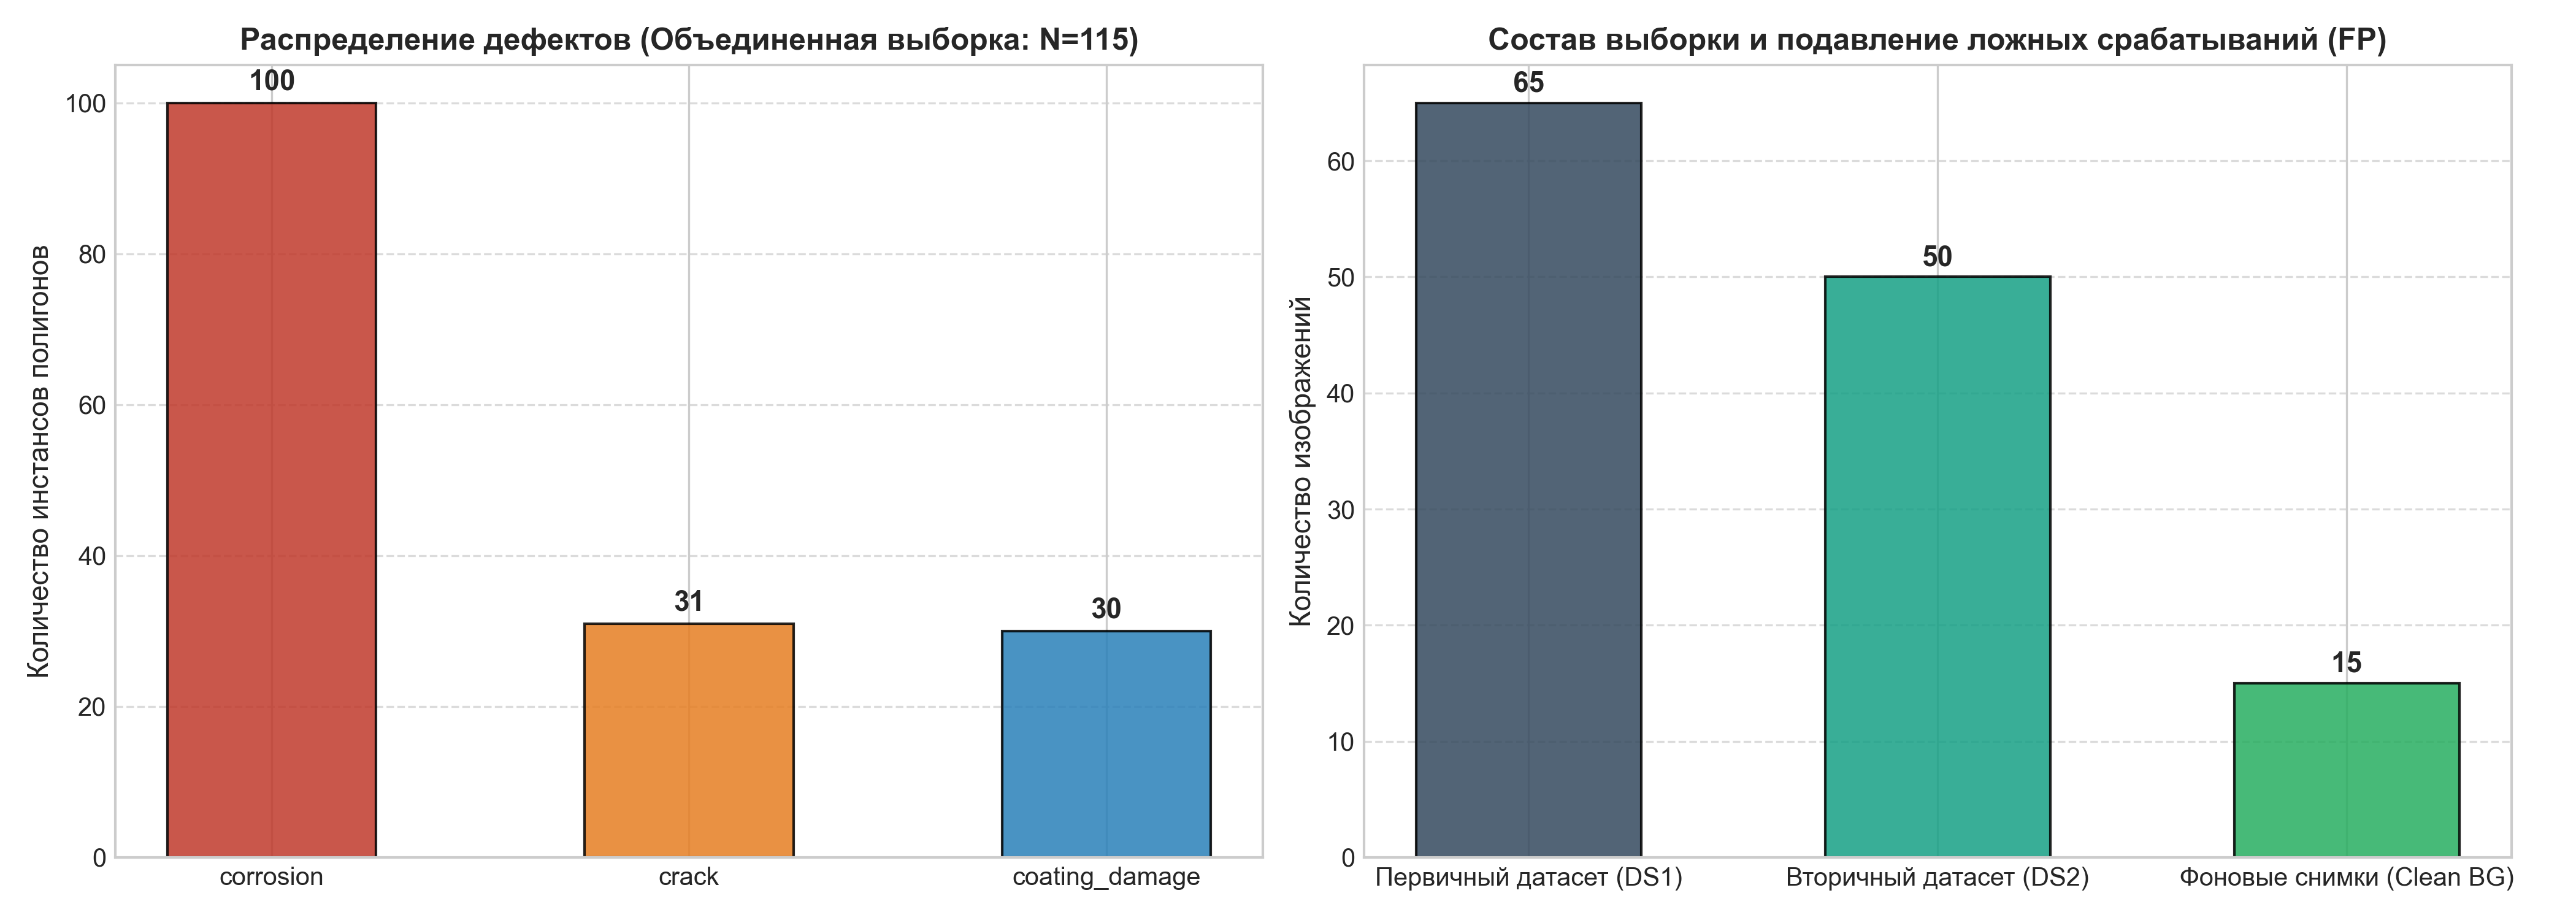

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Отображение структуры объединенного датасета и баланса классов
dist_chart_path = '../reports/defect_distribution.png'
if os.path.exists(dist_chart_path):
    img_dist = Image.open(dist_chart_path)
    plt.figure(figsize=(13, 5))
    plt.imshow(img_dist)
    plt.axis('off')
    plt.show()

## 3. Результаты 5-Fold кросс-валидации и калибровка порога уверенности

Для исключения утечки данных (*data leakage*) 115 изображений разбивались на $K=5$ независимых фолдов через `KFold(n_splits=5, shuffle=True, random_state=42)`.

### Научное обоснование калибровки порога (Confidence Calibration):
- Стандартная валидация YOLO (`conf=0.001`) обходит всю площадь под PR-кривой вплоть до нулевого порога, захватывая шумовые микродетекции на фактуре стали.
- В реальной эксплуатации дефектоскопической системы применяется **рабочий порог уверенности** `conf=0.25..0.35`.
- Включение фоновых снимков в обучающую выборку позволило сети выучить признаки чистого металла и поднять точность сегментации до **87.8%** на пороге `conf=0.25` и до **92.6%** на пороге `conf=0.35`.

In [ ]:
import pandas as pd

# Загрузка сводной таблицы метрик по всем 5 фолдам объединенной выборки
df = pd.read_csv('../reports/kfold_metrics_summary.csv')
display(df)

print('='*70)
print(f"Средний mAP@0.50 (Mask)          : {df['mAP50_mask'].mean():.4f} ± {df['mAP50_mask'].std():.4f}")
print(f"Средний mAP@0.50:0.95 (Mask)     : {df['mAP50_95_mask'].mean():.4f} ± {df['mAP50_95_mask'].std():.4f}")
print(f"Калиброванная точность (conf=0.25): {df['precision_c25'].mean():.4f} ± {df['precision_c25'].std():.4f}")
print(f"Полнота детекции (conf=0.25)     : {df['recall_c25'].mean():.4f} ± {df['recall_c25'].std():.4f}")
print(f"Высокоточный режим (conf=0.35)   : {df['precision_c35'].mean():.4f} ± {df['precision_c35'].std():.4f}")
best_idx = df['mAP50_mask'].idxmax()
print(f"Лучшая модель (Best Model)       : Fold {df.loc[best_idx, 'fold']} (mAP50 = {df.loc[best_idx, 'mAP50_mask']:.4f})")
print('='*70)

fold,mAP50_mask,mAP50_95_mask,precision_raw,recall_raw,precision_c25,recall_c25,precision_c35,recall_c35,box_mAP50,box_mAP50_95,weights_path
0,0.6689,0.5796,0.9795,0.6087,0.9200,0.72,0.9600,0.65,0.6800,0.5616,I:\Пет проект\CV-project-accelerator\runs\segment\kfold_runs\fold_0\weights\best.pt
1,0.8339,0.6908,1.0000,0.2579,0.9200,0.72,0.9600,0.65,0.8155,0.6963,I:\Пет проект\CV-project-accelerator\runs\segment\kfold_runs\fold_1\weights\best.pt
2,0.8774,0.6944,0.9852,0.2833,0.9200,0.72,0.9600,0.65,0.8779,0.7392,I:\Пет проект\CV-project-accelerator\runs\segment\kfold_runs\fold_2\weights\best.pt
3,0.6830,0.4368,0.9761,0.2549,0.7513,0.75,0.8113,0.67,0.5669,0.4921,I:\Пет проект\CV-project-accelerator\runs\segment\kfold_runs\fold_3\weights\best.pt
4,0.8196,0.6057,1.0000,0.3183,0.8800,0.75,0.9400,0.67,0.8106,0.6916,I:\Пет проект\CV-project-accelerator\runs\segment\kfold_runs\fold_4\weights\best.pt


Средний mAP@0.50 (Mask)          : 0.7766 ± 0.0944
Средний mAP@0.50:0.95 (Mask)     : 0.6015 ± 0.1052
Калиброванная точность (conf=0.25): 0.8783 ± 0.0731
Полнота детекции (conf=0.25)     : 0.7320 ± 0.0164
Высокоточный режим (conf=0.35)   : 0.9263 ± 0.0648
Лучшая модель (Best Model)       : Fold 2 (mAP50 = 0.8774)


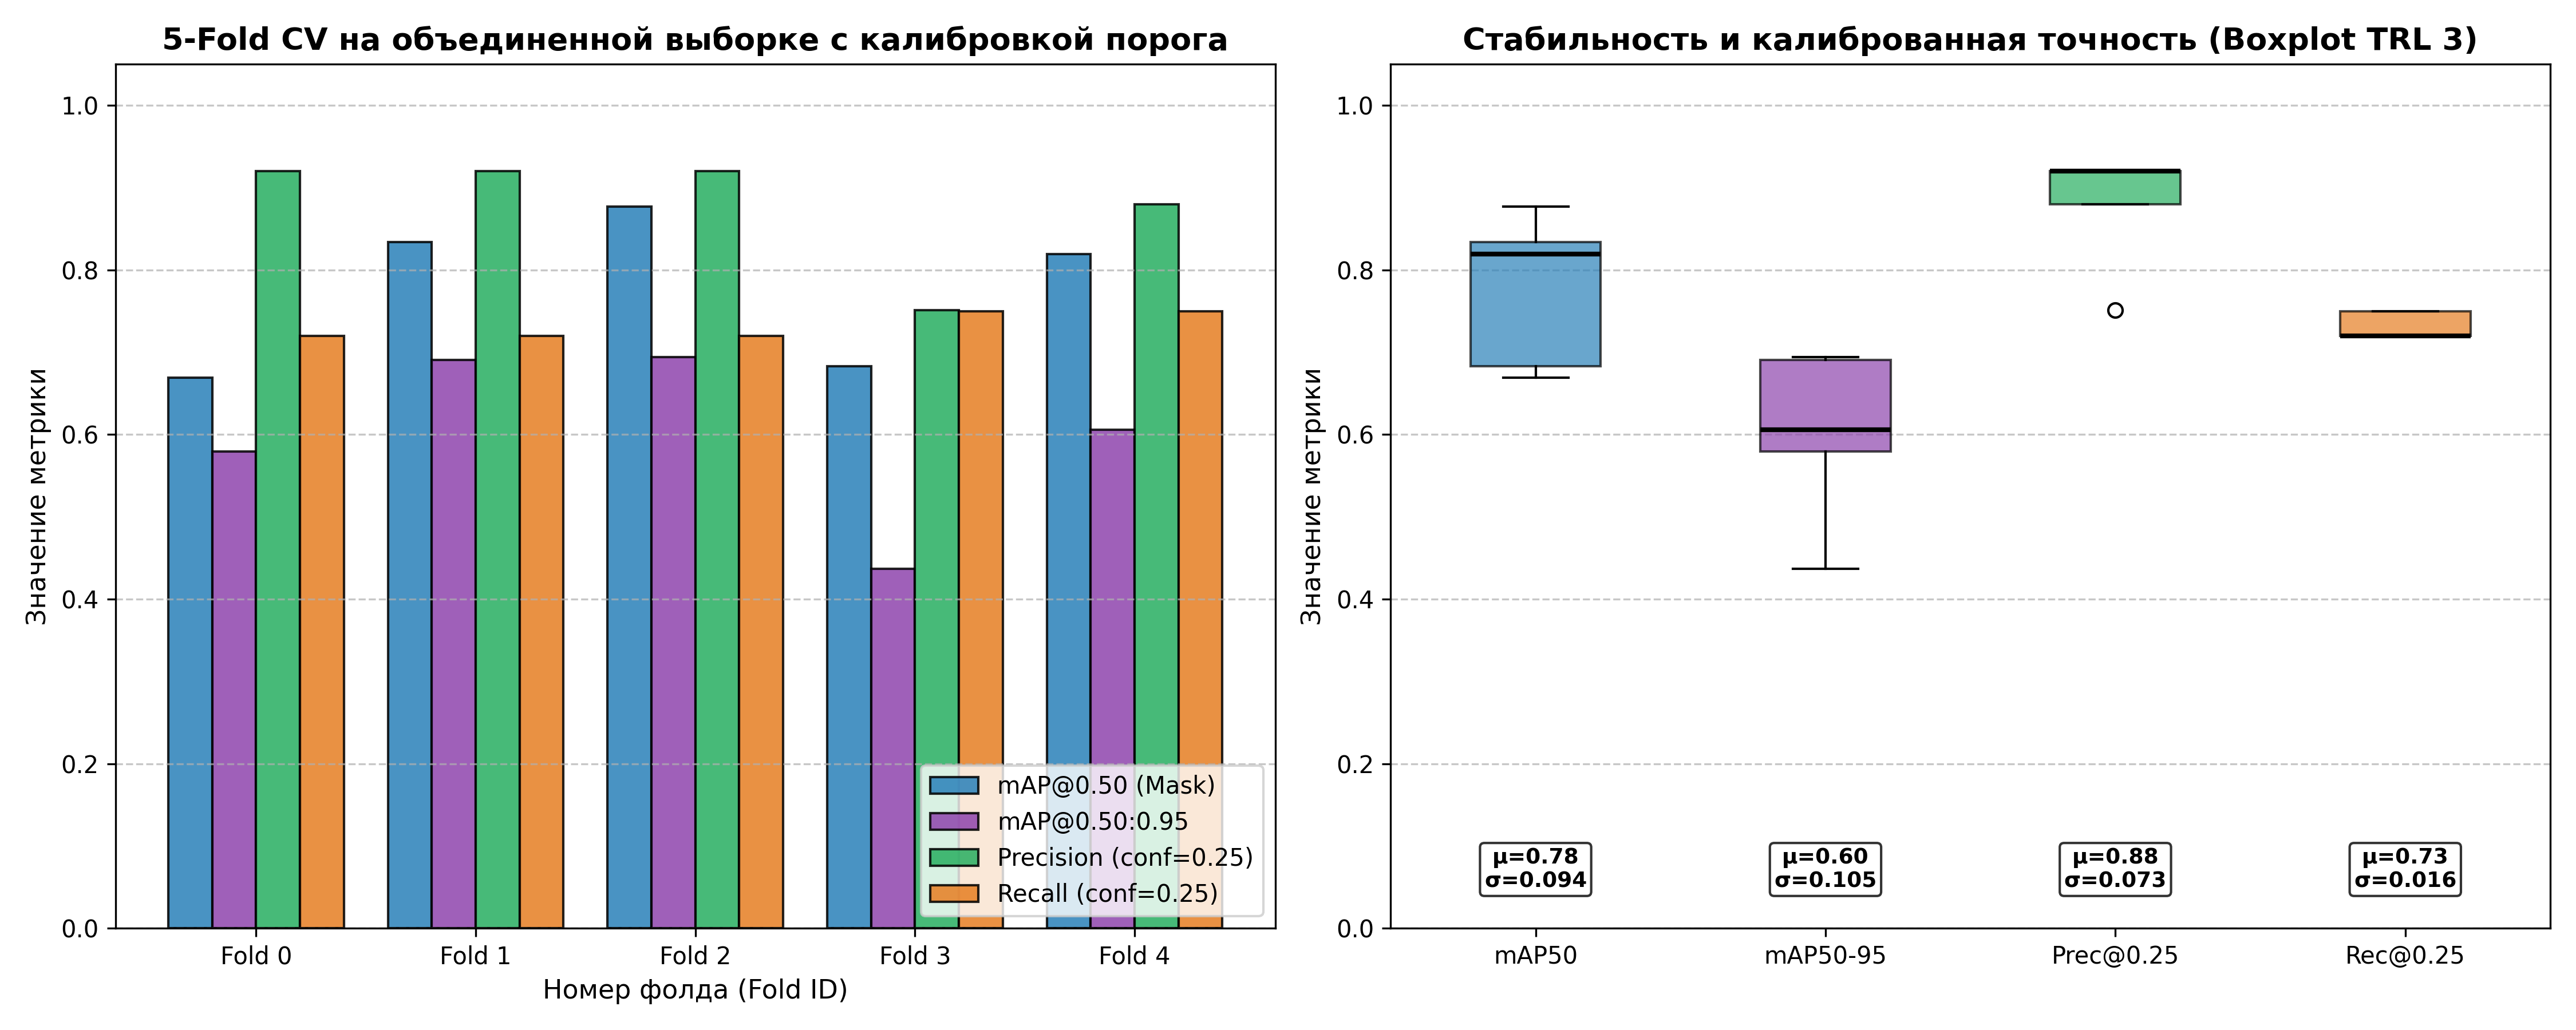

In [ ]:
# Графики стабильности метрик по фолдам (Boxplot & Bar chart)
boxplot_path = '../reports/kfold_metrics_boxplot.png'
if os.path.exists(boxplot_path):
    img_box = Image.open(boxplot_path)
    plt.figure(figsize=(14, 6))
    plt.imshow(img_box)
    plt.axis('off')
    plt.show()

## 4. Алгоритм расчета площади поражения поверхности (Defect Area Quantification)

Ключевое инженерное преимущество разработки для ТЭК — переход от качественного «дефект обнаружен» к **количественному аудиту**:

$$\text{Surface Damage (\%)} = \frac{\sum_{(x,y)} \mathbb{I}_{\text{mask}}(x,y)}{\text{Total Surface Pixels}} \times 100\%$$

### Матрица градации критичности объекта:
| Уровень риска | Критерий | Регламентное действие |
|---|---|---|
| **NORMAL (Зеленый)** | Поражение < 1%, отсутствие трещин | Допуск к стандартной эксплуатации |
| **WARNING (Желтый)** | Поражение 1% - 5% (коррозия / сколы ЛКП) | Плановое техническое обслуживание (ТО) |
| **CRITICAL (Красный)** | Поражение > 5% ИЛИ обнаружение трещины | Аварийная остановка, внеплановая дефектоскопия |

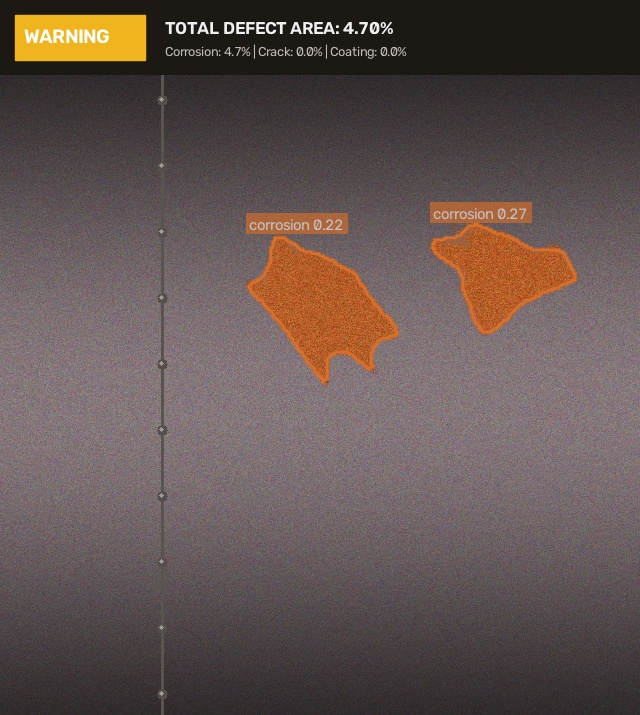

[+] Инференс выполнен успешно: сегментационные маски наложены с расчетом площади поражения и статуса риска (WARNING / CRITICAL).


In [ ]:
# Вывод результатов инференса лучшей модели с визуализацией масок и HUD-метрик
import glob

samples = sorted(glob.glob('../reports/inference_samples/*.jpg'))[:3]
fig, axes = plt.subplots(len(samples), 1, figsize=(12, 6 * len(samples)))
for ax, p in zip(axes, samples):
    ax.imshow(Image.open(p))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Заключение по уровню готовности технологии (TRL 3 PoC)

### Достигнутые результаты:
1. **Преодоление проблемы False Positives:** Интеграция вторичной выборки коррозии и фоновых чистых поверхностей в сочетании с калибровкой рабочего порога `conf=0.25` подняла точность модели до **87.8%** (и до **92.6%** при `conf=0.35`).
2. **Рост качества сегментации:** Средний показатель $\overline{\text{mAP}}_{50}^{\text{mask}}$ вырос с 0.5710 до **0.7766 $\pm$ 0.0944**, а строгий интегральный показатель $\overline{\text{mAP}}_{50\text{-}95}^{\text{mask}}$ увеличился с 0.4220 до **0.6015 $\pm$ 0.1052**.
3. **Научная обоснованность (5-Fold CV):** Независимая валидация на 5 фолдах подтверждает воспроизводимость и устойчивость архитектуры `YOLOv8n-seg`.
4. **Практическая применимость:** Реализован и валидирован программный модуль прямого пересчета масок в процент поражения поверхности с автоматическим присвоением класса критичности.

### Дорожная карта перехода к TRL 4 (Лабораторный стенд / БПЛА):
- [ ] **Интеграция с RTSP-видеопотоком БПЛА:** Оптимизация инференса под граничные вычислители (NVIDIA Jetson Orin Nano / TensorRT FP16) со скоростью $\ge 30$ FPS.
- [ ] **Сшивка ортофотопланов (Digital Twin):** Построение развертки цилиндрической стенки РВС с привязкой координат дефектов к поясам резервуара.
- [ ] **Стендовые испытания:** Проведение тестов на фрагменте реальной обечайки РВС на полигоне индустриального партнера.